# 1) import libraries

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
import datetime

# 2) load dataset

In [75]:
data=pd.read_csv("carprice_ml_pro.csv")
df=pd.DataFrame(data)
df

,it,ft,bt,km,transmission,ownerNo,owner,oem,model,modelYear,...,Cargo Volumn,Alloy Wheel Size_2,City,Gear Box_1,Rear Brake Type_1,Front Brake Type_1,Acceleration_1,Top Speed_1,Drive Type_1,Turning Radius_1
0,0,Petrol,Hatchback,"1,20,000",Manual,3,3rd Owner,Maruti,Maruti Celerio,2015,...,235-litres,NaN,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,Petrol,SUV,"32,706",Manual,2,2nd Owner,Ford,Ford Ecosport,2018,...,352-litres,16,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,Petrol,Hatchback,"11,949",Manual,1,1st Owner,Tata,Tata Tiago,2018,...,242-litres,14,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,Petrol,Sedan,"17,794",Manual,1,1st Owner,Hyundai,Hyundai Xcent,2014,...,407-litres,14,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,Diesel,SUV,"60,000",Manual,1,1st Owner,Maruti,Maruti SX4 S Cross,2015,...,353-litres,16,Bangalore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,0,Petrol,Hatchback,"10,000",Manual,1,1st Owner,Maruti,Maruti Celerio,2022,...,313,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8365,0,Petrol,Hatchback,"1,20,000",Manual,1,1st Owner,Maruti,Maruti Alto 800,2014,...,177-litres,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8366,0,Petrol,Sedan,"50,000",Automatic,3,3rd Owner,Mercedes-Benz,Mercedes-Benz C-Class,2011,...,475-litres,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8367,0,Petrol,Hatchback,"40,000",Manual,1,1st Owner,Maruti,Maruti Ritz,2012,...,236-liters,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
df.tail()

,it,ft,bt,km,transmission,ownerNo,owner,oem,model,modelYear,...,Cargo Volumn,Alloy Wheel Size_2,City,Gear Box_1,Rear Brake Type_1,Front Brake Type_1,Acceleration_1,Top Speed_1,Drive Type_1,Turning Radius_1
8364,0,Petrol,Hatchback,"10,000",Manual,1,1st Owner,Maruti,Maruti Celerio,2022,...,313,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8365,0,Petrol,Hatchback,"1,20,000",Manual,1,1st Owner,Maruti,Maruti Alto 800,2014,...,177-litres,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8366,0,Petrol,Sedan,"50,000",Automatic,3,3rd Owner,Mercedes-Benz,Mercedes-Benz C-Class,2011,...,475-litres,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8367,0,Petrol,Hatchback,"40,000",Manual,1,1st Owner,Maruti,Maruti Ritz,2012,...,236-liters,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8368,0,Diesel,SUV,"1,20,000",Manual,2,2nd Owner,Renault,Renault Duster,2017,...,410-litres,NaN,Kolkata,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
df.shape

(8369, 88)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8369 entries, 0 to 8368
Data columns (total 88 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   it                        8369 non-null   int64  
 1   ft                        8369 non-null   object 
 2   bt                        8365 non-null   object 
 3   km                        8369 non-null   object 
 4   transmission              8369 non-null   object 
 5   ownerNo                   8369 non-null   int64  
 6   owner                     8369 non-null   object 
 7   oem                       8369 non-null   object 
 8   model                     8369 non-null   object 
 9   modelYear                 8369 non-null   int64  
 10  centralVariantId          8369 non-null   int64  
 11  variantName               8369 non-null   object 
 12  price                     8369 non-null   object 
 13  priceActual               1670 non-null   object 
 14  priceSav

In [79]:
df.columns

Index(['it', 'ft', 'bt', 'km', 'transmission', 'ownerNo', 'owner', 'oem',
       'model', 'modelYear', 'centralVariantId', 'variantName', 'price',
       'priceActual', 'priceSaving', 'priceFixedText', 'trendingText.imgUrl',
       'trendingText.heading', 'trendingText.desc', 'Registration Year',
       'Insurance Validity', 'Fuel Type', 'Seats', 'Kms Driven', 'RTO',
       'Ownership', 'Engine Displacement', 'Transmission',
       'Year of Manufacture', 'Mileage', 'Engine', 'Max Power', 'Torque',
       'Seats_1', 'Wheel Size', 'Color', 'Engine Type', 'Displacement',
       'Max Power_1', 'Max Torque', 'No of Cylinder', 'Values per Cylinder',
       'Value Configuration', 'Fuel Suppy System', 'BoreX Stroke',
       'Compression Ratio', 'Turbo Charger', 'Super Charger',
       'Seating Capacity', 'Steering Type', 'Tyre Type', 'Alloy Wheel Size',
       'No Door Numbers', 'Length', 'Width', 'Height', 'Wheel Base',
       'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight',
      

# 3) Find New Feature

In [80]:
df["Length"].unique()

array(['3715mm', '3998mm', '3746mm', '3995mm', '4300mm', '4395mm',
       '3785mm', '3995 mm', '4490 mm', '3765mm', '3955 mm', '4585mm',
       '4436mm', '3993', '4440mm', '4841mm', '3845mm', '4360', '5246mm',
       '3610 mm', '3565mm', '5063mm', '4701mm', '4405mm', '3599mm',
       '4395 mm', '4686mm', '4936mm', '4695 mm', '3985mm', '4530mm',
       '4933mm', '3445mm', '4430mm', '3850mm', '4315mm', '5075mm',
       '3495mm', '5120mm', '4661mm', '5089mm', '3731mm', '3994mm',
       '3810mm', '3695mm', '4386mm', '4270mm', '4598mm', '3840mm',
       '4824mm', '4490mm', '3955mm', '4498mm', '4670mm', '3775mm',
       '3970mm', '4413mm', '3675mm', '4708', '3636mm', '3585mm', '3679mm',
       '4635mm', '4720mm', '3610mm', '3620mm', '3991mm', '4390mm',
       '4425mm', '4655mm', '4500mm', '4234mm', '4531mm', '4838mm',
       '4629mm', '3530mm', '3940 mm', '4892mm', '3886mm', '3700mm',
       '4886mm', '4520mm', '4475mm', '4795mm', '4598 mm', '4656 mm',
       '4331mm', '3971mm', '4575mm', '4

In [81]:
df["Width"].unique()

array(['1635mm', '1765mm', '1647mm', '1660mm', '1785mm', '1818mm',
       '1770 mm', '1730 mm', '1745mm', '1694 mm', '1890mm', '2020mm',
       '1710mm', '1811', '1695mm', '1846mm', '1735', '1822', '2130mm',
       '1645 mm', '1525mm', '1860mm', '2040mm', '1495mm', '1735 mm',
       '2126mm', '1840 mm', '1734mm', '1775mm', '1874mm', '1515mm',
       '1817mm', '1727mm', '1800mm', '2065mm', '1475mm', '2141mm',
       '1894mm', '2177mm', '1579mm', '1811mm', '1665mm', '1655', '1699mm',
       '1780mm', '1735mm', '1828mm', '1730mm', '1694mm', '1751mm',
       '1814mm', '1680mm', '1682mm', '1715mm', '2138', '1595mm', '2097mm',
       '1821 mm', '1835mm', '1750', '1550mm', '1790mm', '1819mm',
       '1822mm', '2089mm', '1490', '1710 mm', '1690mm', '1739', '1938mm',
       '1850mm', '1855mm', '1894 mm', '1729mm', '1890 mm', '2000mm',
       '1820mm', '1992mm', '1760mm', '1902mm', '1813mm', '1,730 mm',
       '1900mm', '1854mm', '1776mm', '1730', '1,634 mm', '2218 mm',
       '1877mm', '1796mm'

In [82]:
df["Height"].unique()

array(['1565mm', '1647mm', '1535mm', '1520mm', '1595mm', '1640mm',
       '1490mm', '1605 mm', '1485 mm', '1510mm', '1544 mm', '1785mm',
       '1611mm', '1505mm', '1606', '1495mm', '1468mm', '1530', '1695',
       '1494mm', '1560 mm', '1590mm', '1427mm', '1700mm', '1690 mm',
       '1442mm', '1466mm', '1850 mm', '1470mm', '1455mm', '1475mm',
       '1975mm', '1414mm', '1645mm', '1460mm', '1850mm', '1786mm',
       '1737mm', '1474mm', '1607mm', '1515mm', '1555', '1630mm', '1706mm',
       '1530mm', '1508mm', '1485mm', '1544mm', '1697mm', '1476mm',
       '1620mm', '1453mm', '1655mm', '1676', '1670mm', '1550mm', '1478mm',
       '1484mm', '1627 mm', '1760mm', '1500mm', '1605', '1467mm',
       '1675mm', '1665mm', '1635mm', '1573mm', '1421mm', '1482mm',
       '1695mm', '1520', '1505 mm', '1837mm', '1525mm', '1643', '1762mm',
       '1660mm', '1835mm', '1706 mm', '1639 mm', '1671mm', '1469mm',
       '1680mm', '1446mm', '1538mm', '1626 mm', '1515', '1685mm',
       '1708mm', '1,487 mm', 

In [83]:
current_year=datetime.datetime.now().year
current_year

2025

In [84]:
df["Car Age"]=current_year-df["modelYear"]
df["Car Age"]

0       10
1        7
2        7
3       11
4       10
        ..
8364     3
8365    11
8366    14
8367    13
8368     8
Name: Car Age, Length: 8369, dtype: int64

In [85]:
df["Length"]=df["Length"].str.replace("mm","").str.replace(",","").str.strip().astype(float)
df["Width"]=df["Width"].str.replace("mm","").str.replace(",","").str.strip().astype(float)
df["Height"]=df["Height"].str.replace("mm","").str.replace(",","").str.replace("-","").str.strip().astype(float)

In [86]:
df["Car Size"]=df["Length"]*df["Width"]*df["Height"]
df["Car Size"].unique()

array([9.50584912e+09, 1.16220061e+10, 9.47043117e+09, 1.00801840e+10,
       1.22424225e+10, 1.31037804e+10, 9.22082775e+09, 1.13491958e+10,
       1.15350345e+10, 1.05266252e+10, 9.49984800e+09, 1.03444449e+10,
       1.54681852e+10, 1.44357199e+10, 1.02813322e+10, 1.16135047e+10,
       1.12510710e+10, 1.31187614e+10, 1.02067448e+10, 1.34649444e+10,
       1.66939261e+10, 9.26398200e+09, 8.64423375e+09, 1.40692669e+10,
       1.36849871e+10, 1.31335956e+10, 9.14685850e+09, 1.28867992e+10,
       1.36495682e+10, 1.53841102e+10, 1.59817800e+10, 1.03995350e+10,
       1.18199025e+10, 1.34506631e+10, 7.69828312e+09, 1.58973872e+10,
       9.40161530e+09, 1.27767150e+10, 1.56674131e+10, 7.52648250e+09,
       2.02795520e+10, 1.57666901e+10, 1.92437940e+10, 8.68370103e+09,
       1.16236463e+10, 9.61062975e+09, 9.50917488e+09, 1.09243593e+10,
       1.23889780e+10, 1.48568921e+10, 1.01934720e+10, 1.32979542e+10,
       1.33655686e+10, 1.25037569e+10, 1.02740400e+10, 1.06721431e+10,
      

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8369 entries, 0 to 8368
Data columns (total 90 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   it                        8369 non-null   int64  
 1   ft                        8369 non-null   object 
 2   bt                        8365 non-null   object 
 3   km                        8369 non-null   object 
 4   transmission              8369 non-null   object 
 5   ownerNo                   8369 non-null   int64  
 6   owner                     8369 non-null   object 
 7   oem                       8369 non-null   object 
 8   model                     8369 non-null   object 
 9   modelYear                 8369 non-null   int64  
 10  centralVariantId          8369 non-null   int64  
 11  variantName               8369 non-null   object 
 12  price                     8369 non-null   object 
 13  priceActual               1670 non-null   object 
 14  priceSav

# 3) select only important features

In [88]:
selected_feature=['Car Age','Car Size','ft', 'bt', 'km', 'transmission', 'ownerNo','oem',
                  'model', 'modelYear', 'price','Insurance Validity','Mileage', 'Engine',
                  ' Seats','Color','City']


In [89]:
df.columns

Index(['it', 'ft', 'bt', 'km', 'transmission', 'ownerNo', 'owner', 'oem',
       'model', 'modelYear', 'centralVariantId', 'variantName', 'price',
       'priceActual', 'priceSaving', 'priceFixedText', 'trendingText.imgUrl',
       'trendingText.heading', 'trendingText.desc', 'Registration Year',
       'Insurance Validity', 'Fuel Type', 'Seats', 'Kms Driven', 'RTO',
       'Ownership', 'Engine Displacement', 'Transmission',
       'Year of Manufacture', 'Mileage', 'Engine', 'Max Power', 'Torque',
       'Seats_1', 'Wheel Size', 'Color', 'Engine Type', 'Displacement',
       'Max Power_1', 'Max Torque', 'No of Cylinder', 'Values per Cylinder',
       'Value Configuration', 'Fuel Suppy System', 'BoreX Stroke',
       'Compression Ratio', 'Turbo Charger', 'Super Charger',
       'Seating Capacity', 'Steering Type', 'Tyre Type', 'Alloy Wheel Size',
       'No Door Numbers', 'Length', 'Width', 'Height', 'Wheel Base',
       'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight',
      

In [90]:
new_df=df.drop(columns=['it', 'owner',  'centralVariantId', 'variantName',
       'priceActual', 'priceSaving', 'priceFixedText', 'trendingText.imgUrl',
       'trendingText.heading', 'trendingText.desc', 'Registration Year',
       'Fuel Type', 'Kms Driven', 'RTO',
       'Ownership', 'Engine Displacement', 'Transmission',
       'Year of Manufacture', 'Max Power', 'Torque',
       'Seats_1', 'Wheel Size', 'Engine Type', 'Displacement',
       'Max Power_1', 'Max Torque', 'No of Cylinder', 'Values per Cylinder',
       'Value Configuration', 'Fuel Suppy System', 'BoreX Stroke',
       'Compression Ratio', 'Turbo Charger', 'Super Charger',
       'Seating Capacity', 'Steering Type', 'Tyre Type', 'Alloy Wheel Size',
       'No Door Numbers', 'Length', 'Width', 'Height', 'Wheel Base',
       'Front Tread', 'Rear Tread', 'Kerb Weight', 'Gross Weight',
       'Ground Clearance Unladen', 'Seating Capacity_1', 'Steering Type_1',
       'Tyre Type_1', 'Alloy Wheel Size_1', 'No Door Numbers_1', 'Gear Box',
       'Drive Type', 'Seating Capacity_2', 'Steering Type_2', 'Turning Radius',
       'Front Brake Type', 'Rear Brake Type', 'Top Speed', 'Acceleration',
       'Tyre Type_2', 'No Door Numbers_2', 'Cargo Volumn',
       'Alloy Wheel Size_2', 'Gear Box_1', 'Rear Brake Type_1',
       'Front Brake Type_1', 'Acceleration_1', 'Top Speed_1', 'Drive Type_1',
       'Turning Radius_1'],inplace=True)
new_df

In [91]:
df.columns

Index(['ft', 'bt', 'km', 'transmission', 'ownerNo', 'oem', 'model',
       'modelYear', 'price', 'Insurance Validity', 'Seats', 'Mileage',
       'Engine', 'Color', 'City', 'Car Age', 'Car Size'],
      dtype='object')

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8369 entries, 0 to 8368
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ft                  8369 non-null   object 
 1   bt                  8365 non-null   object 
 2   km                  8369 non-null   object 
 3   transmission        8369 non-null   object 
 4   ownerNo             8369 non-null   int64  
 5   oem                 8369 non-null   object 
 6   model               8369 non-null   object 
 7   modelYear           8369 non-null   int64  
 8   price               8369 non-null   object 
 9   Insurance Validity  8365 non-null   object 
 10  Seats               8363 non-null   object 
 11  Mileage             8082 non-null   object 
 12  Engine              8365 non-null   object 
 13  Color               8366 non-null   object 
 14  City                8369 non-null   object 
 15  Car Age             8369 non-null   int64  
 16  Car Si

# handle numerical columns

In [93]:
df["price"].unique()

array(['₹ 4 Lakh', '₹ 8.11 Lakh', '₹ 5.85 Lakh', ..., '₹ 1.58 Lakh',
       '₹ 35,000 ', '₹ 10.82 Lakh'], shape=(1400,), dtype=object)

In [94]:
df["km"]=df["km"].str.replace(",","").str.strip().astype(float)
df["Insurance Validity"]=df["Insurance Validity"].str.replace("2","Second Party").str.replace("1","First Party").str.strip()
df["Seats"]=df["Seats"].str.replace("Seats","").str.strip().astype(float)
df["Mileage"]=df["Mileage"].str.replace("kmpl","").str.replace("km/kg",'').str.strip().astype(float)
df["Engine"]=df["Engine"].str.replace("CC","").str.strip().astype(float)
df["price"]=df["price"].str.replace("Lakh","").str.replace("Crore","").str.replace(",","").str.replace("₹","").str.strip().astype(float)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8369 entries, 0 to 8368
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ft                  8369 non-null   object 
 1   bt                  8365 non-null   object 
 2   km                  8369 non-null   float64
 3   transmission        8369 non-null   object 
 4   ownerNo             8369 non-null   int64  
 5   oem                 8369 non-null   object 
 6   model               8369 non-null   object 
 7   modelYear           8369 non-null   int64  
 8   price               8369 non-null   float64
 9   Insurance Validity  8365 non-null   object 
 10  Seats               8363 non-null   float64
 11  Mileage             8082 non-null   float64
 12  Engine              8365 non-null   float64
 13  Color               8366 non-null   object 
 14  City                8369 non-null   object 
 15  Car Age             8369 non-null   int64  
 16  Car Si

In [96]:
df.isnull().sum()

ft                      0
bt                      4
km                      0
transmission            0
ownerNo                 0
oem                     0
model                   0
modelYear               0
price                   0
Insurance Validity      4
Seats                   6
Mileage               287
Engine                  4
Color                   3
City                    0
Car Age                 0
Car Size               83
dtype: int64

# drop duplicate values

In [97]:
df.duplicated().sum()

np.int64(110)

In [98]:
df.shape

(8369, 17)

In [99]:
df.drop_duplicates(inplace=True)

In [100]:
df.shape

(8259, 17)

In [101]:
df.isnull().sum()

ft                      0
bt                      4
km                      0
transmission            0
ownerNo                 0
oem                     0
model                   0
modelYear               0
price                   0
Insurance Validity      4
Seats                   6
Mileage               284
Engine                  4
Color                   3
City                    0
Car Age                 0
Car Size               83
dtype: int64

# drop empty rows

In [102]:
df.dropna(subset=["Mileage"],inplace=True)
df.shape

(7975, 17)

In [103]:
df.dropna(subset=["Car Size"],inplace=True)
df.shape

(7915, 17)

# fill missing values

In [104]:
df["bt"].fillna(df["bt"].mode()[0],inplace=True)
df["Insurance Validity"].fillna(df["Insurance Validity"].mode()[0],inplace=True)
df["Seats"].fillna(df["Seats"].median(),inplace=True)
df["Engine"].fillna(df["Engine"].mode()[0],inplace=True)
df["Color"].fillna(df["Color"].mode()[0],inplace=True)

In [105]:
df.isnull().sum()

ft                    0
bt                    0
km                    0
transmission          0
ownerNo               0
oem                   0
model                 0
modelYear             0
price                 0
Insurance Validity    0
Seats                 0
Mileage               0
Engine                0
Color                 0
City                  0
Car Age               0
Car Size              0
dtype: int64

In [106]:
df["model"].unique()

array(['Maruti Celerio', 'Ford Ecosport', 'Tata Tiago', 'Hyundai Xcent',
       'Maruti SX4 S Cross', 'Jeep Compass', 'Datsun GO', 'Hyundai Venue',
       'Maruti Ciaz', 'Maruti Baleno', 'Hyundai Grand i10', 'Honda Jazz',
       'Mahindra XUV500', 'Hyundai i20', 'Tata Nexon', 'Honda City',
       'BMW 5 Series', 'Maruti Swift', 'Renault Duster',
       'Mercedes-Benz S-Class', 'Hyundai Santro', 'Hyundai Santro Xing',
       'Mercedes-Benz E-Class', 'Audi A4', 'Maruti Wagon R',
       'Maruti Ertiga', 'Mercedes-Benz C-Class', 'Toyota Fortuner',
       'Hyundai Elantra', 'Audi A6', 'Maruti Alto 800',
       'Mahindra Scorpio', 'Mini 3 DOOR', 'Kia Seltos', 'Maruti Alto',
       'Mercedes-Benz GL-Class', 'Tata New Safari', 'Audi Q7',
       'Renault KWID', 'Hyundai Getz', 'Skoda Rapid', 'Hyundai Creta',
       'Tata Harrier', 'BMW 3 Series GT', 'Renault Lodgy',
       'Skoda Octavia', 'Maruti Ritz', 'Volkswagen Polo',
       'Mahindra KUV 100', 'BMW X3', 'Hyundai i10', 'Volvo S60',
       

# Dealing With Outlier

# visualise the data

# price

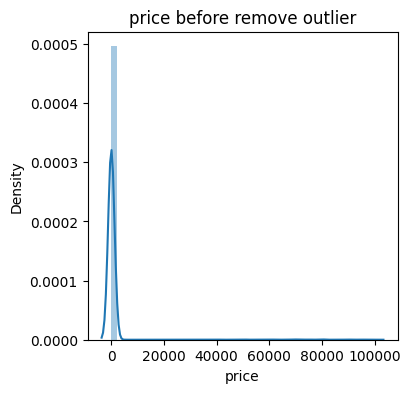

In [107]:
plt.figure(figsize=(4,4))
sns.distplot(df["price"])
plt.title("price before remove outlier")
plt.show()

In [108]:
q1=df["price"].quantile(0.25)
q3=df["price"].quantile(0.75)
iqr=q3-q1
lf=q1-1.5*iqr
uf=q3+1.5*iqr
dff=df[(df["price"]>lf)&(df['price']<uf)]
dff

,ft,bt,km,transmission,ownerNo,oem,model,modelYear,price,Insurance Validity,Seats,Mileage,Engine,Color,City,Car Age,Car Size
0,Petrol,Hatchback,120000.0,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,5.0,23.10,998.0,White,Bangalore,10,9.505849e+09
1,Petrol,SUV,32706.0,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,5.0,17.00,1497.0,White,Bangalore,7,1.162201e+10
2,Petrol,Hatchback,11949.0,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,5.0,23.84,1199.0,Red,Bangalore,7,9.470431e+09
3,Petrol,Sedan,17794.0,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,5.0,19.10,1197.0,Others,Bangalore,11,1.008018e+10
4,Diesel,SUV,60000.0,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,5.0,23.65,1248.0,Gray,Bangalore,10,1.224242e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Petrol,Hatchback,10000.0,Manual,1,Maruti,Maruti Celerio,2022,5.10,Third Party insurance,5.0,25.24,998.0,Others,Kolkata,3,9.509175e+09
8365,Petrol,Hatchback,120000.0,Manual,1,Maruti,Maruti Alto 800,2014,1.80,Third Party insurance,5.0,22.74,796.0,Others,Kolkata,11,7.461361e+09
8366,Petrol,Sedan,50000.0,Automatic,3,Mercedes-Benz,Mercedes-Benz C-Class,2011,5.50,Third Party insurance,5.0,11.74,1796.0,Others,Kolkata,14,1.175842e+10
8367,Petrol,Hatchback,40000.0,Manual,1,Maruti,Maruti Ritz,2012,1.40,Third Party insurance,5.0,18.50,1197.0,Others,Kolkata,13,1.027404e+10


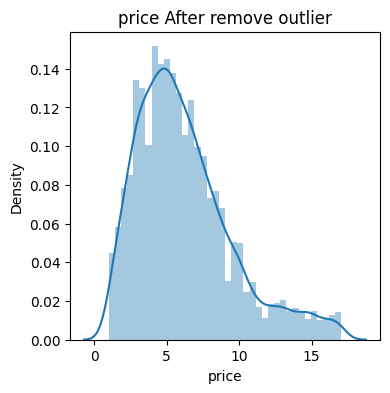

In [109]:
plt.figure(figsize=(4,4))
sns.distplot(dff["price"])
plt.title("price After remove outlier")
plt.show()

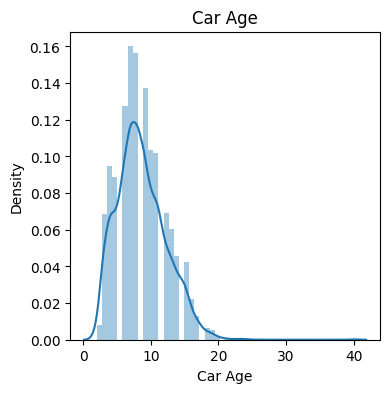

In [110]:
plt.figure(figsize=(4,4))
sns.distplot(dff["Car Age"])
plt.title("Car Age")
plt.show()

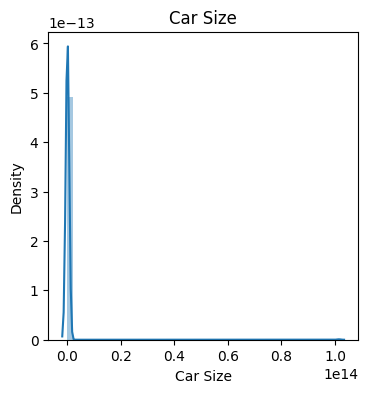

In [111]:
plt.figure(figsize=(4,4))
sns.distplot(dff["Car Size"])
plt.title("Car Size")
plt.show()

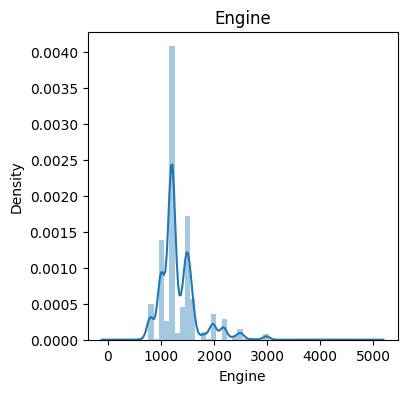

In [112]:
plt.figure(figsize=(4,4))
sns.distplot(dff["Engine"])
plt.title("Engine")
plt.show()

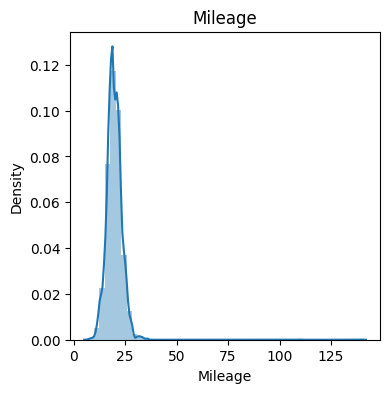

In [113]:
plt.figure(figsize=(4,4))
sns.distplot(dff["Mileage"])
plt.title("Mileage")
plt.show()

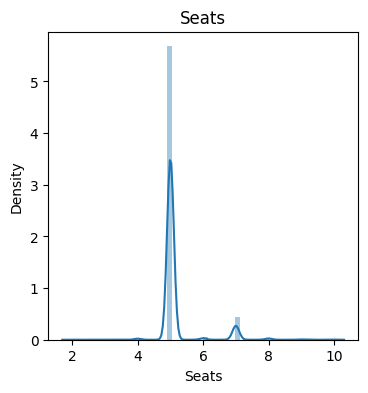

In [114]:
plt.figure(figsize=(4,4))
sns.distplot(dff["Seats"])
plt.title("Seats")
plt.show()

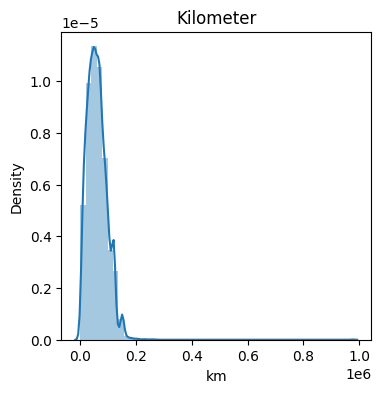

In [115]:
plt.figure(figsize=(4,4))
sns.distplot(dff["km"])
plt.title("Kilometer")
plt.show()

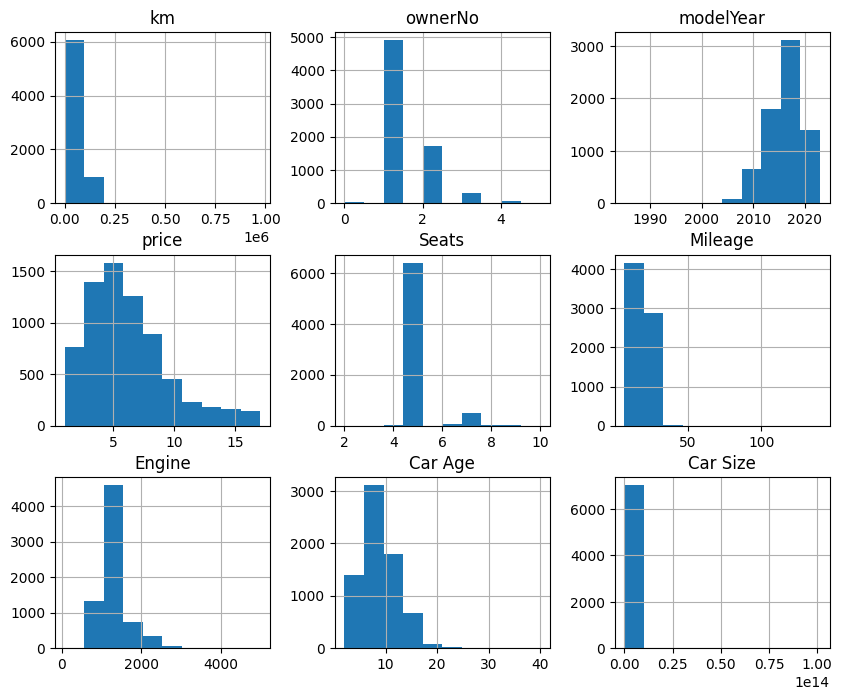

In [116]:
dff.hist(figsize=(10,8))
plt.show()

In [117]:
df["model"].unique()

array(['Maruti Celerio', 'Ford Ecosport', 'Tata Tiago', 'Hyundai Xcent',
       'Maruti SX4 S Cross', 'Jeep Compass', 'Datsun GO', 'Hyundai Venue',
       'Maruti Ciaz', 'Maruti Baleno', 'Hyundai Grand i10', 'Honda Jazz',
       'Mahindra XUV500', 'Hyundai i20', 'Tata Nexon', 'Honda City',
       'BMW 5 Series', 'Maruti Swift', 'Renault Duster',
       'Mercedes-Benz S-Class', 'Hyundai Santro', 'Hyundai Santro Xing',
       'Mercedes-Benz E-Class', 'Audi A4', 'Maruti Wagon R',
       'Maruti Ertiga', 'Mercedes-Benz C-Class', 'Toyota Fortuner',
       'Hyundai Elantra', 'Audi A6', 'Maruti Alto 800',
       'Mahindra Scorpio', 'Mini 3 DOOR', 'Kia Seltos', 'Maruti Alto',
       'Mercedes-Benz GL-Class', 'Tata New Safari', 'Audi Q7',
       'Renault KWID', 'Hyundai Getz', 'Skoda Rapid', 'Hyundai Creta',
       'Tata Harrier', 'BMW 3 Series GT', 'Renault Lodgy',
       'Skoda Octavia', 'Maruti Ritz', 'Volkswagen Polo',
       'Mahindra KUV 100', 'BMW X3', 'Hyundai i10', 'Volvo S60',
       

# Scaling And Encoding

In [118]:
dff=dff.rename(columns={"ft":"Fuel Type","bt":"Body Type","transmission":"Transmission","ownerNo":"Owner No","model":"Model",
                        "modelYear":"Model Year","price":"Price","km":"Kilometer","oem":"Brand"})
dff

,Fuel Type,Body Type,Kilometer,Transmission,Owner No,Brand,Model,Model Year,Price,Insurance Validity,Seats,Mileage,Engine,Color,City,Car Age,Car Size
0,Petrol,Hatchback,120000.0,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,5.0,23.10,998.0,White,Bangalore,10,9.505849e+09
1,Petrol,SUV,32706.0,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,5.0,17.00,1497.0,White,Bangalore,7,1.162201e+10
2,Petrol,Hatchback,11949.0,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,5.0,23.84,1199.0,Red,Bangalore,7,9.470431e+09
3,Petrol,Sedan,17794.0,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,5.0,19.10,1197.0,Others,Bangalore,11,1.008018e+10
4,Diesel,SUV,60000.0,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,5.0,23.65,1248.0,Gray,Bangalore,10,1.224242e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8364,Petrol,Hatchback,10000.0,Manual,1,Maruti,Maruti Celerio,2022,5.10,Third Party insurance,5.0,25.24,998.0,Others,Kolkata,3,9.509175e+09
8365,Petrol,Hatchback,120000.0,Manual,1,Maruti,Maruti Alto 800,2014,1.80,Third Party insurance,5.0,22.74,796.0,Others,Kolkata,11,7.461361e+09
8366,Petrol,Sedan,50000.0,Automatic,3,Mercedes-Benz,Mercedes-Benz C-Class,2011,5.50,Third Party insurance,5.0,11.74,1796.0,Others,Kolkata,14,1.175842e+10
8367,Petrol,Hatchback,40000.0,Manual,1,Maruti,Maruti Ritz,2012,1.40,Third Party insurance,5.0,18.50,1197.0,Others,Kolkata,13,1.027404e+10


In [119]:
dff.columns

Index(['Fuel Type', 'Body Type', 'Kilometer', 'Transmission', 'Owner No',
       'Brand', 'Model', 'Model Year', 'Price', 'Insurance Validity', 'Seats',
       'Mileage', 'Engine', 'Color', 'City', 'Car Age', 'Car Size'],
      dtype='object')

In [120]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
dff["Fuel Type"]=le.fit_transform(dff["Fuel Type"])
dff["Body Type"]=le.fit_transform(dff["Body Type"])
dff["Transmission"]=le.fit_transform(dff["Transmission"])
dff["Brand"]=le.fit_transform(dff["Brand"])
dff["Model"]=le.fit_transform(dff["Model"])
dff["Color"]=le.fit_transform(dff["Color"])
dff["Insurance Validity"]=le.fit_transform(dff["Insurance Validity"])
dff["City"]=le.fit_transform(dff["City"])
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7046 entries, 0 to 8368
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Fuel Type           7046 non-null   int64  
 1   Body Type           7046 non-null   int64  
 2   Kilometer           7046 non-null   float64
 3   Transmission        7046 non-null   int64  
 4   Owner No            7046 non-null   int64  
 5   Brand               7046 non-null   int64  
 6   Model               7046 non-null   int64  
 7   Model Year          7046 non-null   int64  
 8   Price               7046 non-null   float64
 9   Insurance Validity  7046 non-null   int64  
 10  Seats               7046 non-null   float64
 11  Mileage             7046 non-null   float64
 12  Engine              7046 non-null   float64
 13  Color               7046 non-null   int64  
 14  City                7046 non-null   int64  
 15  Car Age             7046 non-null   int64  
 16  Car Size   

# split x and y

In [121]:
x=dff.drop("Price",axis=1)
y=dff["Price"]

In [122]:
x.shape,y.shape

((7046, 16), (7046,))

In [123]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
x_scaled=std.fit_transform(x)
x_scaled.shape

(7046, 16)

# train test split

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)
x_train.shape

(5636, 16)

In [126]:
x_test.shape

(1410, 16)

# model 1 : linear regression

In [127]:
from sklearn.linear_model import LinearRegression
model_reg=LinearRegression()
model_reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
y_pred=model_reg.predict(x_test)
y_pred

array([5.08490439, 6.31921133, 4.53832126, ..., 7.11024683, 5.27371677,
       6.79320688], shape=(1410,))

In [129]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score
print("mean squared error :",mean_squared_error(y_pred,y_test))
print("Root mean squared error :",root_mean_squared_error(y_pred,y_test))
print("mean absolute error :",mean_absolute_error(y_pred,y_test))
print("r2 scored :",r2_score(y_pred,y_test))

mean squared error : 4.06919799054607
Root mean squared error : 2.0172253197265966
mean absolute error : 1.3828748569176026
r2 scored : 0.4471396355291877


In [130]:
y_pred_train=model_reg.predict(x_train)
print("mean squared error :",mean_squared_error(y_pred_train,y_train))
print("Root mean squared error :",root_mean_squared_error(y_pred_train,y_train))
print("mean absolute error :",mean_absolute_error(y_pred_train,y_train))
print("r2 scored :",r2_score(y_pred_train,y_train))

mean squared error : 3.691620859916631
Root mean squared error : 1.9213591178945781
mean absolute error : 1.3524508464979967
r2 scored : 0.49615966402162914


# model 2 : randomforest regression

In [131]:
from sklearn.ensemble import RandomForestRegressor
model_rf=RandomForestRegressor()
model_rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [132]:
y_pred_rf=model_rf.predict(x_test)
y_pred_rf

array([2.9881, 3.5873, 4.725 , ..., 8.2228, 5.8653, 5.3693], shape=(1410,))

In [133]:
print("mean squared error :",mean_squared_error(y_pred_rf,y_test))
print("Root mean squared error :",root_mean_squared_error(y_pred_rf,y_test))
print("mean absolute error :",mean_absolute_error(y_pred_rf,y_test))
print("r2 scored :",r2_score(y_pred_rf,y_test))

mean squared error : 1.285168079956693
Root mean squared error : 1.1336525393420565
mean absolute error : 0.727782505633846
r2 scored : 0.8638825862367093


In [134]:
y_pred_train_rf=model_rf.predict(x_train)
y_pred_train

array([6.42930697, 5.6098997 , 6.94483757, ..., 5.06024315, 3.94432264,
       4.13194156], shape=(5636,))

In [135]:
print("mean squared error :",mean_squared_error(y_pred_train_rf,y_train))
print("Root mean squared error :",root_mean_squared_error(y_pred_train_rf,y_train))
print("mean absolute error :",mean_absolute_error(y_pred_train_rf,y_train))
print("r2 scored :",r2_score(y_pred_train_rf,y_train))

mean squared error : 0.1812282122054056
Root mean squared error : 0.4257090699120769
mean absolute error : 0.2686546396951363
r2 scored : 0.9821152597117635


# model 3 : decision tree

In [136]:
from sklearn.tree import DecisionTreeRegressor
decision_tree_model=DecisionTreeRegressor()
decision_tree_model.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [137]:
y_pred_dt=decision_tree_model.predict(x_test)
y_pred_dt

array([2.99, 3.5 , 5.25, ..., 7.65, 6.84, 5.  ], shape=(1410,))

In [138]:
print("mean squared error :",mean_squared_error(y_pred_dt,y_test))
print("Root mean squared error :",root_mean_squared_error(y_pred_dt,y_test))
print("mean absolute error :",mean_absolute_error(y_pred_dt,y_test))
print("r2 scored :",r2_score(y_pred_dt,y_test))

mean squared error : 2.6366946631205677
Root mean squared error : 1.6237902152435109
mean absolute error : 0.9988049645390071
r2 scored : 0.7708644327078442


# model 4 : support vector regressor

In [139]:
from sklearn.svm import SVR
svr_model=SVR()
svr_model.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [140]:
y_pred_svr=svr_model.predict(x_test)
y_pred_svr

array([3.98990192, 4.00492684, 4.32907726, ..., 7.28017115, 5.64912628,
       6.1253432 ], shape=(1410,))

In [141]:
print("mean squared error :",mean_squared_error(y_pred_svr,y_test))
print("Root mean squared error :",root_mean_squared_error(y_pred_svr,y_test))
print("mean absolute error :",mean_absolute_error(y_pred_svr,y_test))
print("r2 scored :",r2_score(y_pred_svr,y_test))

mean squared error : 2.400143058641361
Root mean squared error : 1.5492395097728953
mean absolute error : 0.9846538289236648
r2 scored : 0.7029704708624208


# model 5 : K - Nearest Neighbour Classification

In [142]:
from sklearn.neighbors import KNeighborsRegressor
knn_model=KNeighborsRegressor()
knn_model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [143]:
y_pred_knn=knn_model.predict(x_test)
y_pred_knn

array([3.8  , 3.768, 4.13 , ..., 8.212, 5.684, 7.748], shape=(1410,))

In [144]:
print("mean squared error :",mean_squared_error(y_pred_knn,y_test))
print("Root mean squared error :",root_mean_squared_error(y_pred_knn,y_test))
print("mean absolute error :",mean_absolute_error(y_pred_knn,y_test))
print("r2 scored :",r2_score(y_pred_knn,y_test))

mean squared error : 2.7702847063829785
Root mean squared error : 1.6644172272549267
mean absolute error : 1.1370936170212764
r2 scored : 0.6521961518966166


# model perfomance comparison 

In [147]:
model_names=["LinearRegression","Decision tree","svc","Knn","RandomForestRegressor"]
MSE=[0.06,2.63,2.40,2.77,1.28]
RMSE=[2.01,1.62,1.54,1.66,1.13]
MAE=[1.38,0.99,0.98,1.13,0.72]
R2_SCORE=[0.44,0.77,0.70,0.65,0.86]

# create dictionary

In [148]:
metrics_dict={
    "MODEL NAME":model_names,
    "MSE":MSE,
    "RMSE":RMSE,
    "MAE":MAE,
    "R2_SCORE":R2_SCORE
    }

# Create Dataframe

In [149]:
metrics_df=pd.DataFrame(metrics_dict)
metrics_df

,MODEL NAME,MSE,RMSE,MAE,R2_SCORE
0,LinearRegression,0.06,2.01,1.38,0.44
1,Decision tree,2.63,1.62,0.99,0.77
2,svc,2.40,1.54,0.98,0.70
3,Knn,2.77,1.66,1.13,0.65
4,RandomForestRegressor,1.28,1.13,0.72,0.86
